DATA CLEANING AND PREPROCESSING

Objective:
The purpose of data cleaning and preprocessing is to improve data quality by handling missing values,removing inconsistencies and preparing the dataset for analysis and visualization.

IMPORT REQUIRED LIBRARIES

Before stating the analysis,the required python libraries are imported

In [2]:
import pandas as pd
import numpy as np

Explanation:
pandas is used for data manipulation and analysis.
numpy is used for numerical operations.

LOAD THE DATASET

The dataset is loaded into a Pandas DataFrame

In [7]:
df = pd.read_csv("loan_dataset_20000.csv")

Explanation: The read_csv() function read the CSV file(loan_dataset_20000.csv) and stores it in a DataFrame named df. 

EXPLORE THE DATASET

In [8]:
print(df.head())


   age  gender marital_status education_level  annual_income  monthly_income  \
0   59    Male        Married        Master's       24240.19         2020.02   
1   72  Female        Married      Bachelor's       20172.98         1681.08   
2   49  Female         Single     High School       26181.80         2181.82   
3   35  Female         Single     High School       11873.84          989.49   
4   63   Other         Single           Other       25326.44         2110.54   

  employment_status  debt_to_income_ratio  credit_score  loan_amount  ...  \
0          Employed                 0.074           743     17173.72  ...   
1          Employed                 0.219           531     22663.89  ...   
2          Employed                 0.234           779      3631.36  ...   
3          Employed                 0.264           809     14939.23  ...   
4          Employed                 0.260           663     16551.71  ...   

  loan_term  installment  grade_subgrade  num_of_open_ac

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  str    
 2   marital_status        20000 non-null  str    
 3   education_level       20000 non-null  str    
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  str    
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  str    
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  str    
 15  num_of_open_accounts  20000 no

In [10]:
print(df.shape)

(20000, 22)


Explanation:We started by examining the dataset using head(),info(),shape these functions  helped us to understand the dataset dimensions,datatypes,and statistical information.  

CHECK MISSING VALUES 

In [11]:
print(df.isnull().sum())

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64


Explanation: identifies missing values in each column.
Missing values can affect analysis and model performance.

CHECK DUPLICATE RECORDS

In [12]:
print(df.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool


VERIFY DATA TYPES

In [13]:
print(df.dtypes)

age                       int64
gender                      str
marital_status              str
education_level             str
annual_income           float64
monthly_income          float64
employment_status           str
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
loan_purpose                str
interest_rate           float64
loan_term                 int64
installment             float64
grade_subgrade              str
num_of_open_accounts      int64
total_credit_limit      float64
current_balance         float64
delinquency_history       int64
public_records            int64
num_of_delinquencies      int64
loan_paid_back            int64
dtype: object


HANDLE OUTLIERS:Check outliers using boxplots

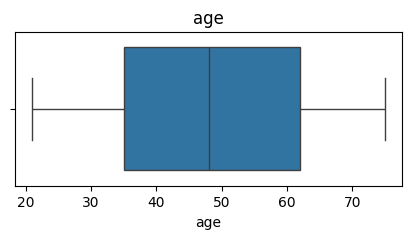

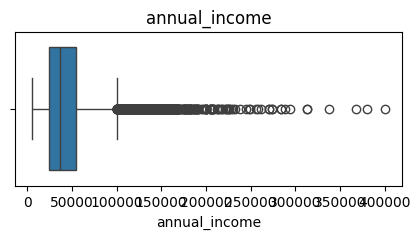

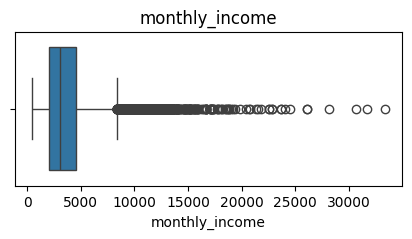

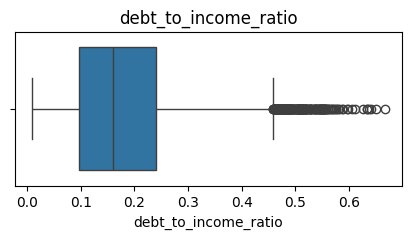

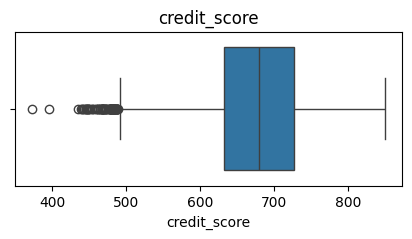

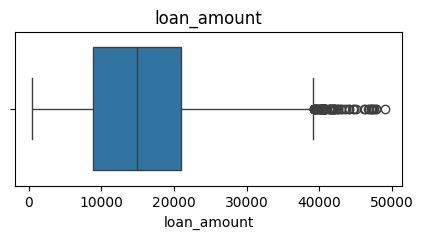

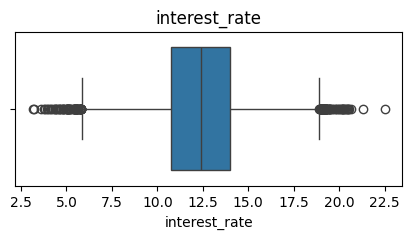

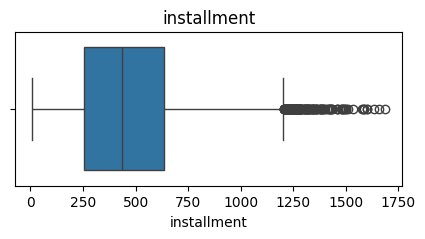

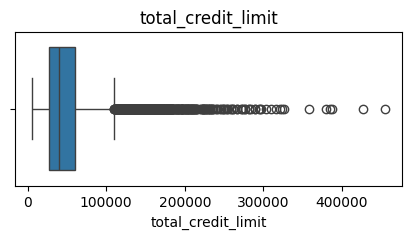

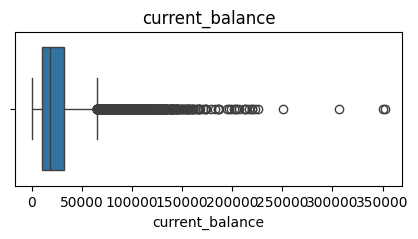

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'age','annual_income','monthly_income',
    'debt_to_income_ratio','credit_score',
    'loan_amount','interest_rate',
    'installment','total_credit_limit',
    'current_balance'
]

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

ENCODE CATEGORICAL COLUMNS

verify dtype of columns before encode categorical columns

In [15]:
cat_col = [col for col in df.columns if df[col].dtype=='string' ]
num_col = [col for col in df.columns if df[col].dtype!='string']
print("cat_col:",cat_col)
print("num_col:",num_col)

cat_col: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
num_col: ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_paid_back']


In [16]:
df[cat_col].nunique()

gender                3
marital_status        4
education_level       5
employment_status     5
loan_purpose          8
grade_subgrade       30
dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'loan_purpose',
    'grade_subgrade'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
print(df["gender"].unique())

[1 0 2]


In [19]:
df[cat_cols].head()

,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,1,1,2,0,1,9
1,0,1,0,0,2,25
2,0,2,1,0,0,8
3,0,2,1,0,6,4
4,2,2,3,0,1,19


dtype after encoding

In [20]:
print(df.dtypes)

age                       int64
gender                    int64
marital_status            int64
education_level           int64
annual_income           float64
monthly_income          float64
employment_status         int64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
loan_purpose              int64
interest_rate           float64
loan_term                 int64
installment             float64
grade_subgrade            int64
num_of_open_accounts      int64
total_credit_limit      float64
current_balance         float64
delinquency_history       int64
public_records            int64
num_of_delinquencies      int64
loan_paid_back            int64
dtype: object


SCALE NUMERICAL FEATURES

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    'monthly_income',
    'debt_to_income_ratio',
    'interest_rate',
    'installment',
    'num_of_open_accounts',
    'total_credit_limit',
    'current_balance',
    'num_of_delinquencies'
]

df[num_cols] = scaler.fit_transform(df[num_cols])

VERIFY FINAL DATASET

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  int64  
 2   marital_status        20000 non-null  int64  
 3   education_level       20000 non-null  int64  
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  int64  
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  int64  
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  int64  
 15  num_of_open_accounts  20000 no

In [24]:
df.describe()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,2.000000e+04,20000.00000,20000.000000,...,20000.00000,2.000000e+04,20000.00000,2.000000e+04,2.000000e+04,2.000000e+04,20000.000000,20000.000000,2.000000e+04,20000.000000
mean,48.027000,0.519800,1.436850,1.055350,43549.637766,-8.171241e-18,0.890850,2.700062e-17,679.25695,15129.300909,...,43.22280,4.263256e-18,14.19650,-7.638334e-18,1.421085e-17,1.776357e-17,1.990150,0.061800,1.421085e-17,0.799900
std,15.829352,0.540946,0.667484,1.117519,28668.579671,1.000025e+00,1.375402,1.000025e+00,69.63858,8605.405513,...,11.00838,1.000025e+00,6.18592,1.000025e+00,1.000025e+00,1.000025e+00,1.474945,0.285105,1.000025e+00,0.400085
min,21.000000,0.000000,0.000000,0.000000,6000.000000,-1.309816e+00,0.000000,-1.589801e+00,373.00000,500.000000,...,36.00000,-1.624803e+00,0.00000,-2.232951e+00,-1.310569e+00,-1.068289e+00,0.000000,0.000000,-1.525828e+00,0.000000
25%,35.000000,0.000000,1.000000,0.000000,24260.752500,-6.728397e-01,0.000000,-7.711959e-01,632.00000,8852.695000,...,36.00000,-7.345396e-01,10.00000,-8.963350e-01,-6.621725e-01,-6.606298e-01,1.000000,0.000000,-9.128365e-01,1.000000
50%,48.000000,0.000000,1.000000,1.000000,36585.260000,-2.429340e-01,0.000000,-1.620011e-01,680.00000,14946.170000,...,36.00000,-7.294130e-02,14.00000,-5.257358e-03,-2.593320e-01,-2.688461e-01,2.000000,0.000000,-2.998448e-01,1.000000
75%,62.000000,1.000000,2.000000,2.000000,54677.917500,3.881804e-01,2.000000,6.090111e-01,727.00000,20998.867500,...,60.00000,6.480674e-01,18.00000,4.402815e-01,3.612124e-01,3.320861e-01,3.000000,0.000000,3.131468e-01,1.000000
max,75.000000,2.000000,3.000000,4.000000,400000.000000,1.243379e+01,4.000000,4.663964e+00,850.00000,49039.690000,...,60.00000,4.478171e+00,29.00000,4.450131e+00,1.251426e+01,1.469279e+01,11.000000,2.000000,5.217080e+00,1.000000


In [25]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,1,1,2,24240.19,-0.673556,0,-0.980607,743,17173.72,...,36,0.459749,9,0.885820,-0.241078,-0.001404,1,0,-0.912836,1
1,72,0,1,0,20172.98,-0.815431,0,0.399600,531,22663.89,...,60,0.428032,25,-0.005257,-0.637883,-0.606382,1,0,0.313147,1
2,49,0,2,1,26181.80,-0.605828,0,0.542380,779,3631.36,...,60,-1.381226,8,-1.341874,-1.022361,-0.888616,0,0,-1.525828,1
3,35,0,2,1,11873.84,-1.104922,0,0.827940,809,14939.23,...,36,0.045315,4,0.885820,-0.940457,-0.842895,4,0,1.539130,1
4,63,2,2,3,25326.44,-0.635665,0,0.789866,663,16551.71,...,60,-0.218946,19,-1.787413,-0.961746,-0.929468,2,0,-0.299845,1


SAVE CLEANED DATASET

In [26]:
df.to_csv("cleaned_loan_dataset.csv",index=False)